# Figure Walkthrough Notebook

This notebook walks through how each report figure is created.

It uses the same project modules and helper functions used by the Python pipeline, but displays figures inline instead of saving them.

In [25]:
from pathlib import Path
import sys

project_root = Path.cwd().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

project_root

WindowsPath('C:/Users/brcol/My Drive/Documents/!!!Resume/Sample Work/Python – Revenue Intelligence & Pipeline Analytics (CRM Data, Forecasting, Time-Series, Power BI)')

In [26]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

import src.analytics_visuals as av
from src.layer_bronze import build_bronze
from src.layer_silver import build_silver
from src.layer_gold import build_gold

from src.pipeline import _build_summary_card_metrics

In [27]:
# Replace the save helper inside the visuals module so helper-based charts render inline only.
def _show_fig_inline(fig, output_dir, name):
    display(fig)
    plt.close(fig)

av._save_fig = _show_fig_inline

## Build The Same Pipeline Inputs

These are the exact medallion builder functions used by the pipeline.

In [28]:
bronze_tables = build_bronze()
silver_tables = build_silver(bronze_tables)
gold_tables = build_gold(silver_tables)
gold_tables.pop('win_prob_model_metrics', None)
gold_tables.pop('forecast_metrics', None)
sorted(gold_tables.keys())

['gold_dim_account',
 'gold_dim_date',
 'gold_dim_product',
 'gold_dim_sales_rep',
 'gold_dim_stage',
 'gold_fct_closed_deals',
 'gold_fct_opportunity_scoring',
 'gold_fct_pipeline_snapshot',
 'gold_mart_customer_performance',
 'gold_mart_forecasting',
 'gold_mart_kpi_summary',
 'gold_mart_pipeline_conversion',
 'gold_mart_product_performance',
 'gold_mart_sales_performance',
 'gold_mart_sales_performance_by_rep',
 'gold_mart_sales_performance_by_team',
 'gold_mart_yearly_summary']

## Shared Summary Card Metrics

These summary stats are generated with the same helper used by `src.pipeline`, so the notebook and Python pipeline stay aligned.


In [29]:
summary_card_metrics = _build_summary_card_metrics(gold_tables)
display(pd.DataFrame(summary_card_metrics).T)


,current_value,display_value,last_quarter_change_ratio,last_quarter_change_pct,definition
as_of_quarter,2017Q4,2017Q4,2017Q4,2017Q4,2017Q4
previous_quarter,2017Q3,2017Q3,2017Q3,2017Q3,2017Q3
closed_deals,6711,6.71K,-0.0303,-3.0%,Count of pursued opportunities with deal_stage...
deals_win,4238,4.24K,-0.0485,-4.9%,Count of won opportunities across the full dat...
deals_lost,2473,2.47K,-0.0013,-0.1%,Count of lost opportunities across the full da...
win_pct,0.6315,63.2%,-0.0188,-1.9%,Won opportunities divided by pursued opportuni...
avg_scl,51.78,51.78,0.0152,1.5%,Average days_to_close for won opportunities wi...
revenue,10005534.0,$10M,-0.0603,-6.0%,Total revenue from won opportunities across th...
avg_revenue,2360.9,$2.36K,-0.0123,-1.2%,Average revenue per won opportunity across the...
avg_closed_deal_size,1490.9,$1.49K,-0.0309,-3.1%,Average revenue per closed opportunity across ...


## Shared Figure Inputs

Several dashboard-style visuals use the same joined closed-deal analysis frame.

In [30]:
closed = av._build_closed_deal_analysis_frame(gold_tables)
won = closed[closed['deal_stage'] == 'Won'].copy()
closed_outcomes = closed[closed['deal_stage'].isin(['Won', 'Lost'])].copy()
display(closed.head())

,date,date_key,created_date_key,activity_date_key,opportunity_id,account_key,sales_rep_key,product_key,stage_key,deal_stage,...,sales_price,account,sector,year_established,revenue_account,employees,office_location,subsidiary_of,product_category,quarter_label
0,2017-03-01,20170301,20161020,20170301,1C1I7A6R,9.0,5,6,4,Won,...,1096,Cancity,retail,2001,718.62,2448,United States,NaN,Standard,Q1 2017
1,2017-03-11,20170311,20161025,20170311,Z063OYW0,39.0,10,2,4,Won,...,4821,Isdom,medical,2002,3178.24,4540,United States,NaN,Standard,Q1 2017
2,2017-03-07,20170307,20161025,20170307,EC4QE1BX,9.0,10,3,4,Won,...,55,Cancity,retail,2001,718.62,2448,United States,NaN,Basic,Q1 2017
3,2017-03-09,20170309,20161025,20170309,MV1LWRNH,11.0,5,1,4,Won,...,550,Codehow,software,1998,2714.90,2641,United States,Acme Corporation,Basic,Q1 2017
4,2017-03-02,20170302,20161025,20170302,PE84CX4O,35.0,33,1,4,Won,...,550,Hatfan,services,1982,792.46,1299,United States,NaN,Basic,Q1 2017


## Monthly Revenue Trend

,date,closed_won_revenue,closed_won_revenue_rolling_3m
0,2016-11-01,0.0,0.0
1,2016-12-01,0.0,0.0
2,2017-01-01,0.0,0.0
3,2017-02-01,0.0,0.0
4,2017-03-01,1134672.0,378224.0


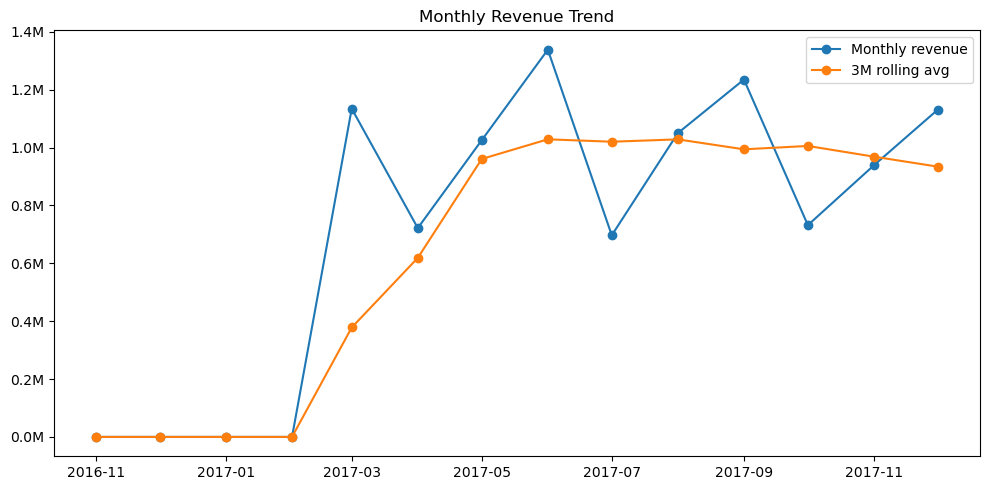

In [31]:
sales_perf = gold_tables['gold_mart_sales_performance'].sort_values('date')
display(sales_perf[['date', 'closed_won_revenue', 'closed_won_revenue_rolling_3m']].head())

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(sales_perf['date'], sales_perf['closed_won_revenue'], label='Monthly revenue', marker='o')
ax.plot(sales_perf['date'], sales_perf['closed_won_revenue_rolling_3m'], label='3M rolling avg', marker='o')
ax.set_title('Monthly Revenue Trend')
av._apply_million_axis_format(ax, axis='y', decimals=1)
ax.legend()
fig.tight_layout()
display(fig)
plt.close(fig)

## Revenue Forecast

,date,forecast_revenue,forecast_type,period_index,month_num,year,month,year_month,date_key
10,2017-09-01,1235264.0,actual,NaN,NaN,2017,9,2017-09,20170901
11,2017-10-01,731980.0,actual,NaN,NaN,2017,10,2017-10,20171001
12,2017-11-01,938943.0,actual,NaN,NaN,2017,11,2017-11,20171101
13,2017-12-01,1131573.0,actual,NaN,NaN,2017,12,2017-12,20171201
14,2018-01-01,1035258.0,forecast,14.0,1.0,2018,1,2018-01,20180101
15,2018-02-01,1035258.0,forecast,15.0,2.0,2018,2,2018-02,20180201
16,2018-03-01,2169930.0,forecast,16.0,3.0,2018,3,2018-03,20180301
17,2018-04-01,1757190.0,forecast,17.0,4.0,2018,4,2018-04,20180401
18,2018-05-01,2060971.0,forecast,18.0,5.0,2018,5,2018-05,20180501
19,2018-06-01,2373724.0,forecast,19.0,6.0,2018,6,2018-06,20180601


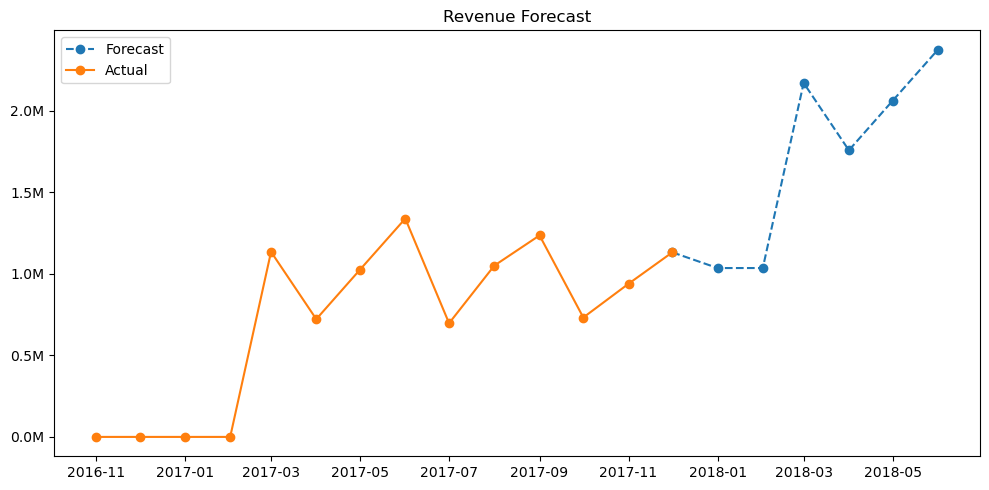

In [32]:
forecast = gold_tables['gold_mart_forecasting'].sort_values('date')
actual = forecast[forecast['forecast_type'] == 'actual']
projected = forecast[forecast['forecast_type'] == 'forecast']
forecast_line = pd.concat([actual.tail(1), projected], ignore_index=True)
display(forecast.tail(10))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(forecast_line['date'], forecast_line['forecast_revenue'], label='Forecast', linestyle='--', marker='o')
ax.plot(actual['date'], actual['forecast_revenue'], label='Actual', marker='o')
ax.set_title('Revenue Forecast')
av._apply_million_axis_format(ax, axis='y', decimals=1)
ax.legend()
fig.tight_layout()
display(fig)
plt.close(fig)

## Deals Won By Sales Agent

,sales_agent,wins
6,Darcel Schlecht,349
26,Vicki Laflamme,221
15,Kary Hendrixson,209
0,Anna Snelling,208
25,Versie Hilleb...,176


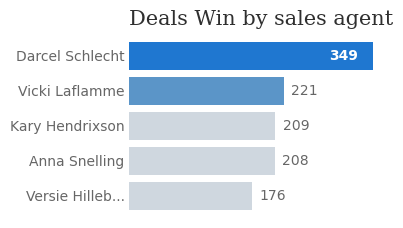

In [33]:
wins_by_agent = won.groupby('sales_agent').size().reset_index(name='wins').sort_values('wins', ascending=False).head(5)
wins_by_agent['sales_agent'] = av._truncate_names(wins_by_agent['sales_agent'])
display(wins_by_agent)

fig, ax = plt.subplots(figsize=(3.3, 2.4))
av._plot_ranked_bar(ax, wins_by_agent, 'sales_agent', 'wins', 'Deals Win by sales agent')
display(fig)
plt.close(fig)

## Revenue By Agent

,sales_agent,deal_revenue
6,Darcel Schlecht,1153214.0
26,Vicki Laflamme,478396.0
15,Kary Hendrixson,454298.0
2,Cassey Cress,450489.0
7,Donn Cantrell,445860.0


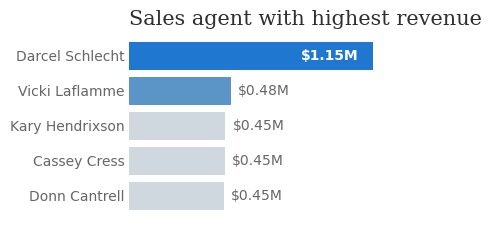

In [34]:
revenue_by_agent = won.groupby('sales_agent', as_index=False)['deal_revenue'].sum().sort_values('deal_revenue', ascending=False).head(5)
revenue_by_agent['sales_agent'] = av._truncate_names(revenue_by_agent['sales_agent'])
display(revenue_by_agent)

fig, ax = plt.subplots(figsize=(3.3, 2.4))
av._plot_ranked_bar(ax, revenue_by_agent, 'sales_agent', 'deal_revenue', 'Sales agent with highest revenue', value_fmt='${:,.2f}M', show_in_millions=True)
display(fig)
plt.close(fig)

## Average Days To Win

,sales_agent,days_to_close
20,Moses Frase,64.689922
16,Lajuana Vencill,62.866142
27,Violet Mclelland,58.049180
28,Wilburn Farren,56.545455
17,Markita Hansen,55.930769


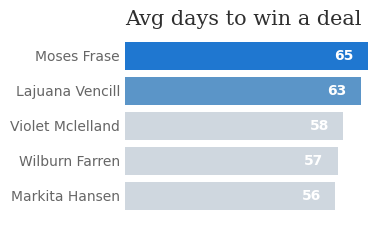

In [35]:
avg_days_to_win = won.groupby('sales_agent', as_index=False)['days_to_close'].mean().sort_values('days_to_close', ascending=False).head(5)
avg_days_to_win['sales_agent'] = av._truncate_names(avg_days_to_win['sales_agent'])
display(avg_days_to_win)

fig, ax = plt.subplots(figsize=(3.3, 2.4))
av._plot_ranked_bar(ax, avg_days_to_win, 'sales_agent', 'days_to_close', 'Avg days to win a deal', value_fmt='{:.0f}')
display(fig)
plt.close(fig)

## Win Percentage

,sales_agent,win_pct
11,Hayden Neloms,70.394737
19,Maureen Marcano,69.953052
28,Wilburn Farren,69.620253
3,Cecily Lampkin,66.875000
25,Versie Hilleb...,66.666667


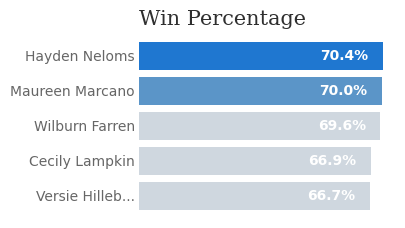

In [36]:
win_percentage = (
    closed_outcomes.groupby('sales_agent')['deal_stage']
    .apply(lambda s: s.eq('Won').mean() * 100)
    .reset_index(name='win_pct')
    .sort_values('win_pct', ascending=False)
    .head(5)
)
win_percentage['sales_agent'] = av._truncate_names(win_percentage['sales_agent'])
display(win_percentage)

fig, ax = plt.subplots(figsize=(3.3, 2.4))
av._plot_ranked_bar(ax, win_percentage, 'sales_agent', 'win_pct', 'Win Percentage', percentage=True)
display(fig)
plt.close(fig)

## Quarter By Product Series Inputs

In [37]:
quarter_series = (
    closed_outcomes.groupby('quarter_label', as_index=False)
    .agg(
        win_rate=('deal_stage', lambda s: s.eq('Won').mean()),
        wins=('deal_stage', lambda s: int(s.eq('Won').sum())),
        revenue=('deal_revenue', lambda s: float(s[closed_outcomes.loc[s.index, 'deal_stage'] == 'Won'].sum())),
        avg_scl=('days_to_close', 'mean'),
    )
)
quarter_series = (
    quarter_series.assign(
        sort_key=pd.PeriodIndex(
            quarter_series['quarter_label'].str[-4:] + 'Q' + quarter_series['quarter_label'].str[1],
            freq='Q',
        )
    )
    .sort_values('sort_key')
    .drop(columns='sort_key')
    .reset_index(drop=True)
)
display(quarter_series)


,quarter_label,win_rate,wins,revenue,avg_scl
0,Q1 2017,0.820711,531,1134672.0,66.528594
1,Q2 2017,0.617126,1254,3086111.0,46.687008
2,Q3 2017,0.614069,1257,2982255.0,44.999511
3,Q4 2017,0.602519,1196,2802496.0,46.349622


## Win % By Quarter

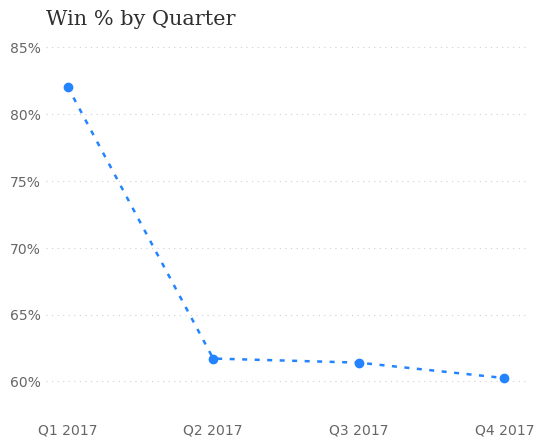

In [38]:
av._plot_quarter_series_chart(quarter_series, 'win_rate', 'Win % by Quarter', Path('.'), 'inline.png', y_as_percent=True)


## Wins By Quarter

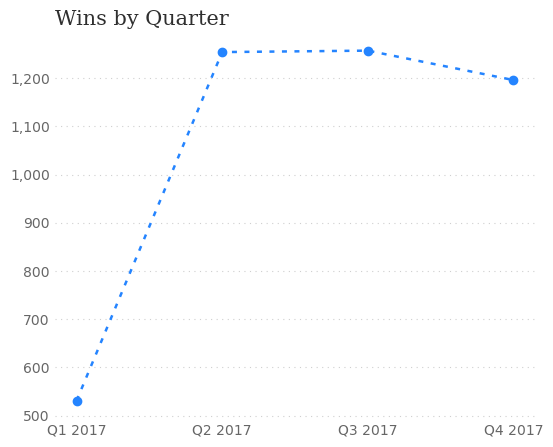

In [39]:
av._plot_quarter_series_chart(quarter_series, 'wins', 'Wins by Quarter', Path('.'), 'inline.png', y_fmt='integer')


## Revenue By Quarter

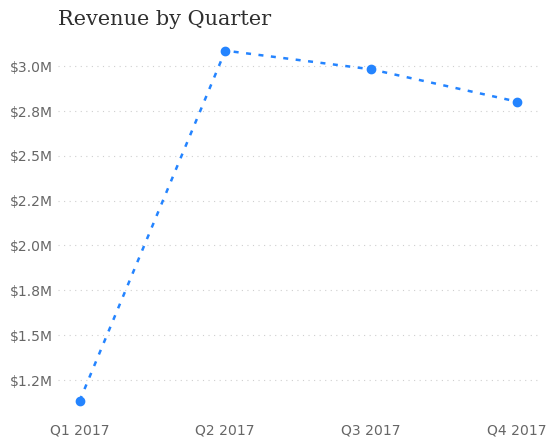

In [40]:
av._plot_quarter_series_chart(quarter_series, 'revenue', 'Revenue by Quarter', Path('.'), 'inline.png', y_fmt='currency_m')


## Avg SCL By Quarter

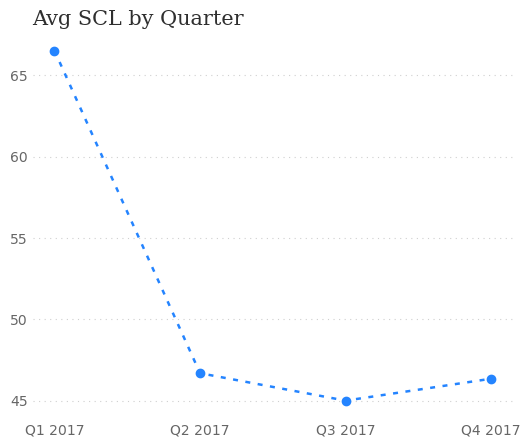

In [41]:
av._plot_quarter_series_chart(quarter_series, 'avg_scl', 'Avg SCL by Quarter', Path('.'), 'inline.png', y_fmt='days')


## Revenue By Product Categories

,product_category,deal_revenue
2,Standard,9061891.0
1,Premium,400612.0
0,Basic,543031.0


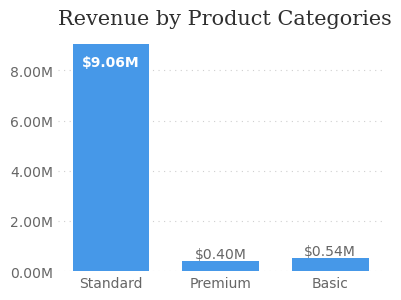

In [42]:
revenue_by_category = won.groupby('product_category', as_index=False)['deal_revenue'].sum().sort_values('deal_revenue', ascending=False)
category_order = ['Standard', 'Premium', 'Basic']
revenue_by_category['product_category'] = pd.Categorical(revenue_by_category['product_category'], categories=category_order, ordered=True)
revenue_by_category = revenue_by_category.sort_values('product_category')
display(revenue_by_category)

fig, ax = plt.subplots(figsize=(4.2, 3.1))
av._style_axis(ax, 'Revenue by Product Categories')
ax.bar(revenue_by_category['product_category'].astype(str), revenue_by_category['deal_revenue'], color='#4698e8', width=0.7)
ax.grid(axis='y', linestyle=(0, (1, 4)), color='#cfcfcf')
ax.set_axisbelow(True)
av._apply_million_axis_format(ax, axis='y', decimals=2)
for position, (_, row) in enumerate(revenue_by_category.iterrows()):
    label_y = row['deal_revenue'] - revenue_by_category['deal_revenue'].max() * 0.08
    label_color = 'white'
    if row['deal_revenue'] < revenue_by_category['deal_revenue'].max() * 0.12:
        label_y = row['deal_revenue'] + revenue_by_category['deal_revenue'].max() * 0.03
        label_color = '#666666'
    ax.text(position, label_y, f"${row['deal_revenue'] / 1_000_000:.2f}M", ha='center', va='center', color=label_color, fontweight='bold' if label_color == 'white' else None)
display(fig)
plt.close(fig)

## Revenue By Product

,product,deal_revenue
4,GTX Pro,3510578.0
3,GTX Plus Pro,2629651.0
5,MG Advanced,2216387.0
2,GTX Plus Basic,705275.0
1,GTX Basic,499263.0
0,GTK 500,400612.0
6,MG Special,43768.0


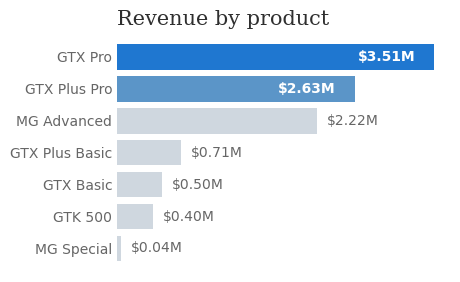

In [43]:
revenue_by_product = won.groupby('product', as_index=False)['deal_revenue'].sum().sort_values('deal_revenue', ascending=False)
revenue_by_product['product'] = av._truncate_names(revenue_by_product['product'], limit=18)
display(revenue_by_product.head(7))

fig, ax = plt.subplots(figsize=(4.3, 3.1))
av._plot_ranked_bar(ax, revenue_by_product.head(7), 'product', 'deal_revenue', 'Revenue by product', value_fmt='${:,.2f}M', show_in_millions=True)
display(fig)
plt.close(fig)

## US Vs Other Countries

,office_location,deal_revenue
14,United States,8426955.0
8,Korea,194957.0
6,Jordan,163339.0
10,Panama,151777.0
5,Japan,123506.0
0,Belgium,117463.0
9,Norway,115712.0
4,Italy,114352.0
7,Kenya,107408.0
12,Poland,106754.0


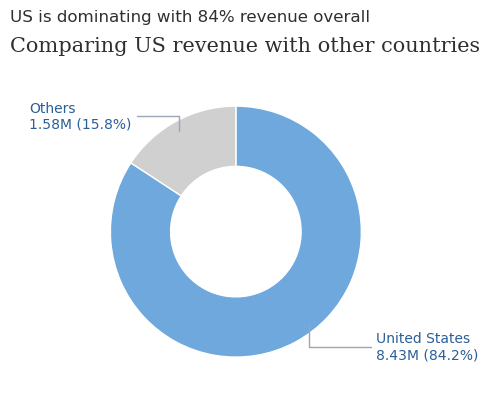

In [44]:
revenue_by_country = won.groupby('office_location', as_index=False)['deal_revenue'].sum()
us_revenue = float(revenue_by_country.loc[revenue_by_country['office_location'] == 'United States', 'deal_revenue'].sum())
other_revenue = float(revenue_by_country.loc[revenue_by_country['office_location'] != 'United States', 'deal_revenue'].sum())
total_country_revenue = us_revenue + other_revenue
display(revenue_by_country.sort_values('deal_revenue', ascending=False).head(10))

fig, ax = plt.subplots(figsize=(6.4, 4.4))
ax.text(0.0, 1.12, f"US is dominating with {us_revenue / total_country_revenue:.0%} revenue overall", transform=ax.transAxes, fontsize=12, color=av.TEXT_DARK)
ax.text(0.0, 1.03, 'Comparing US revenue with other countries', transform=ax.transAxes, fontsize=15, fontfamily='serif', color=av.TEXT_DARK)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(axis='both', length=0, colors='#666666', labelsize=10)
ax.pie([us_revenue, other_revenue], labels=None, colors=['#6fa8dc', '#d0d0d0'], startangle=90, counterclock=False, wedgeprops=dict(width=0.48, edgecolor='white'))
ax.set_aspect('equal')
ax.set_xlim(-1.8, 1.8)
ax.set_ylim(-1.35, 1.35)
ax.annotate(f"Others\n{other_revenue / 1_000_000:.2f}M ({other_revenue / total_country_revenue:.1%})", xy=(-0.45, 0.78), xytext=(-1.65, 0.92), ha='left', va='center', fontsize=10, color='#2a5f98', arrowprops=dict(arrowstyle='-', color='#9aa6b2', lw=1.0, connectionstyle='angle,angleA=0,angleB=90,rad=0'))
ax.annotate(f"United States\n{us_revenue / 1_000_000:.2f}M ({us_revenue / total_country_revenue:.1%})", xy=(0.58, -0.72), xytext=(1.12, -0.92), ha='left', va='center', fontsize=10, color='#2a5f98', arrowprops=dict(arrowstyle='-', color='#9aa6b2', lw=1.0, connectionstyle='angle,angleA=180,angleB=-90,rad=0'))
display(fig)
plt.close(fig)

## Revenue By Sector

,sector,deal_revenue
5,retail,1867528.0
8,technology,1515487.0
4,medical,1359595.0
7,software,1077934.0
2,finance,950908.0
3,marketing,922321.0
1,entertainment,689007.0
9,telecommunications,653574.0
6,services,533006.0
0,employment,436174.0


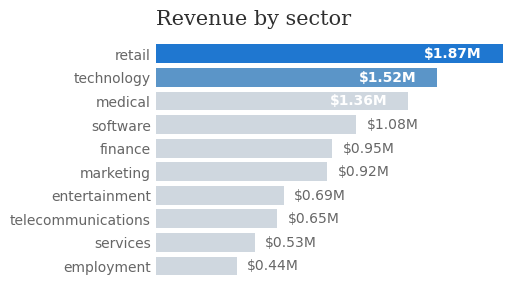

In [45]:
revenue_by_sector = won.groupby('sector', as_index=False)['deal_revenue'].sum().sort_values('deal_revenue', ascending=False)
display(revenue_by_sector.head(10))

fig, ax = plt.subplots(figsize=(4.7, 3.3))
av._plot_ranked_bar(ax, revenue_by_sector.head(10), 'sector', 'deal_revenue', 'Revenue by sector', value_fmt='${:,.2f}M', show_in_millions=True)
display(fig)
plt.close(fig)

## Country Sector Summary Table

In [46]:
country_sector_table = (
    closed_outcomes.groupby(['office_location', 'sector'], as_index=False)
    .agg(
        wins=('deal_stage', lambda s: int(s.eq('Won').sum())),
        closed_opportunities=('deal_stage', 'count'),
        avg_scl=('days_to_close', 'mean'),
        revenue=('deal_revenue', lambda s: float(s[closed_outcomes.loc[s.index, 'deal_stage'] == 'Won'].sum())),
    )
)
country_sector_table['win_pct'] = country_sector_table['wins'] / country_sector_table['closed_opportunities']
country_sector_table['avg_revenue'] = country_sector_table['revenue'] / country_sector_table['wins'].replace(0, pd.NA)
country_sector_table = country_sector_table.sort_values(['office_location', 'revenue'], ascending=[True, False]).head(20).copy()
country_sector_table = country_sector_table.rename(columns={'office_location': 'Country', 'sector': 'Sector'})
country_sector_table['Win %'] = (country_sector_table['win_pct'] * 100).round(1)
country_sector_table['Avg SCL'] = country_sector_table['avg_scl'].round(2)
country_sector_table['Revenue'] = country_sector_table['revenue'].round(0)
country_sector_table['Avg Revenue'] = country_sector_table['avg_revenue'].round(0)
export_table = country_sector_table[['Country', 'Sector', 'wins', 'Win %', 'Avg SCL', 'Revenue', 'Avg Revenue']].rename(columns={'wins': 'Wins'})
display(export_table)

,Country,Sector,Wins,Win %,Avg SCL,Revenue,Avg Revenue
0,Belgium,retail,63,60.6,48.57,117463.0,1864.0
1,Brazil,services,32,61.5,46.21,63103.0,1972.0
2,China,technology,33,68.8,44.40,86690.0,2627.0
3,Germany,services,37,72.5,42.41,82622.0,2233.0
4,Italy,retail,54,62.1,43.92,114352.0,2118.0
5,Japan,retail,46,61.3,48.92,123506.0,2685.0
6,Jordan,marketing,52,64.2,45.57,163339.0,3141.0
7,Kenya,medical,53,61.6,41.79,107408.0,2027.0
8,Korea,technology,111,57.5,48.12,194957.0,1756.0
9,Norway,technology,50,58.8,46.65,115712.0,2314.0
